<a href="https://colab.research.google.com/github/cauarichard/deepfakes/blob/main/id1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive
Device: cpu
Carregando DINOv2...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

The image processor of type `BitImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Dimensão do embedding DINOv2: 768
IDs disponíveis:
- id0
- id1

Digite o ID para treinar (ex: id0): id1
Usando embeddings já existentes em: /content/drive/MyDrive/dataset/modelos_dinov2/embeddings_id1/id1_embeddings.pt

Iniciando treino (usando embeddings)...
Época 1/50 | Train Loss: 0.2474, Acc: 93.38% | Val Loss: 0.2231, Acc: 93.55% | Train AUC: 0.5914, Val AUC: 0.7418 | Val EER: 0.3254, HTER: 0.3254, F1: 0.1346
  -> Melhor AUC de validação até agora, modelo salvo.
Época 2/50 | Train Loss: 0.2071, Acc: 94.17% | Val Loss: 0.1726, Acc: 93.62% | Train AUC: 0.7361, Val AUC: 0.9434 | Val EER: 0.1372, HTER: 0.1372, F1: 0.1682
  -> Melhor AUC de validação até agora, modelo salvo.
Época 3/50 | Train Loss: 0.1663, Acc: 94.63% | Val Loss: 0.1292, Acc: 94.12% | Train AUC: 0.8624, Val AUC: 0.9808 | Val EER: 0.0753, HTER: 0.0753, F1: 0.2545
  -> Melhor AUC de validação até agora, modelo salvo.
Época 4/50 | Train Loss: 0.1408, Acc: 95.24% | Val Loss: 0.1086, Acc: 95.20% | Train AUC: 0.9059, Val AU

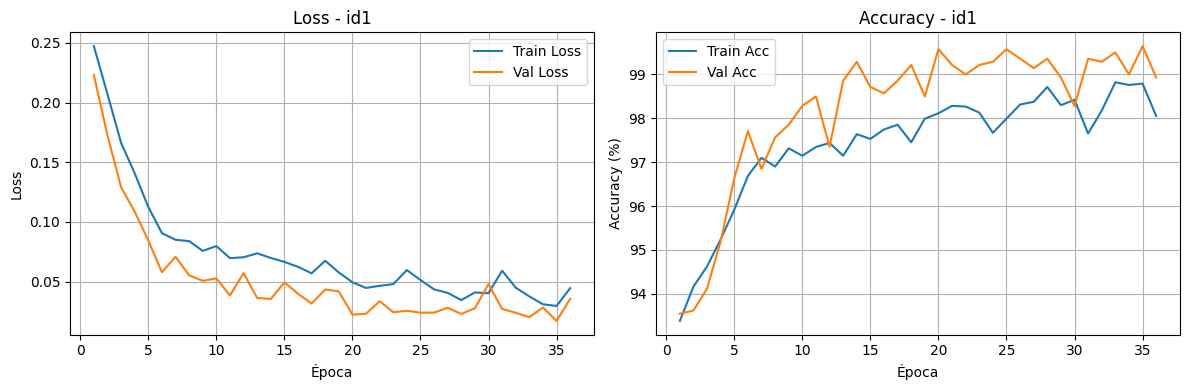

Histórico de treino/val (inclui AUC/EER/HTER/F1) salvo em: /content/drive/MyDrive/dataset/modelos_dinov2/history_id1.csv

Carregando melhor modelo salvo para avaliar no TESTE...

RESULTADOS FINAIS NO TESTE (id1):
Accuracy: 98.71%
AUC:      0.9978
EER:      0.0168
HTER:     0.0168
F1:       0.8594

MATRIZ DE CONFUSÃO (TESTE):
TN: 1324, FP: 1, FN: 17, TP: 55
Sensitivity (TPR): 0.7639
Specificity (TNR): 0.9992

Melhor modelo copiado para: /content/drive/MyDrive/dataset/modelos_dinov2/dinov2_id1_best.pth


In [1]:
# ==============================
# 0) MONTAR O GOOGLE DRIVE
# ==============================
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# Depois de montar, rode o resto desta célula normalmente
import os
import shutil
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torchvision import transforms
from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image as PILImage

from sklearn.metrics import (
    roc_auc_score, f1_score, roc_curve,
    confusion_matrix
)

from transformers import AutoImageProcessor, AutoModel

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from time import time
from tqdm import tqdm

import torch.serialization
from numpy.core.multiarray import _reconstruct
torch.serialization.add_safe_globals([_reconstruct])

# ==============================
# 1) CAMINHOS E CONFIGURAÇÕES
# ==============================
BASE_DIR = "/content/drive/MyDrive/dataset/real_fake/videos_celeb"
FACES_REAIS_ROOT = os.path.join(BASE_DIR, "faces_reais")
FACES_FAKES_ROOT = os.path.join(BASE_DIR, "faces_fakes")

MODELS_ROOT = "/content/drive/MyDrive/dataset/modelos_dinov2"
os.makedirs(MODELS_ROOT, exist_ok=True)

DINOV2_MODEL_NAME = "facebook/dinov2-base"

BATCH_SIZE = 64
NUM_EPOCHS = 50
LR = 1e-3

PATIENCE = 7
MIN_DELTA = 1e-4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ==============================
# 2) DINOv2 (CONGELADO)
# ==============================
print("Carregando DINOv2...")
image_processor = AutoImageProcessor.from_pretrained(DINOV2_MODEL_NAME)
dinov2_backbone = AutoModel.from_pretrained(DINOV2_MODEL_NAME)
dinov2_backbone.to(device)
dinov2_backbone.eval()

for p in dinov2_backbone.parameters():
    p.requires_grad = False

with torch.no_grad():
    dummy_image = PILImage.new("RGB", (518, 518), color=(0, 0, 0))
    dummy_inputs = image_processor(images=dummy_image, return_tensors="pt")
    dummy_pixel_values = dummy_inputs["pixel_values"].to(device)

    out = dinov2_backbone(pixel_values=dummy_pixel_values)
    if hasattr(out, "pooler_output") and out.pooler_output is not None:
        EMBED_DIM = out.pooler_output.shape[-1]
        USE_POOLER = True
    else:
        EMBED_DIM = out.last_hidden_state[:, 0].shape[-1]
        USE_POOLER = False

print("Dimensão do embedding DINOv2:", EMBED_DIM)

def dinov2_embeddings(batch_pixels: torch.Tensor) -> torch.Tensor:
    with torch.no_grad():
        outputs = dinov2_backbone(pixel_values=batch_pixels.to(device))
        if USE_POOLER and hasattr(outputs, "pooler_output") and outputs.pooler_output is not None:
            feats = outputs.pooler_output
        else:
            feats = outputs.last_hidden_state[:, 0]
    return feats

# ==============================
# 3) LISTAR IDs (pastas de faces)
# ==============================
def listar_ids_faces():
    ids_real = []
    ids_fake = []

    if os.path.isdir(FACES_REAIS_ROOT):
        ids_real = [
            d for d in os.listdir(FACES_REAIS_ROOT)
            if os.path.isdir(os.path.join(FACES_REAIS_ROOT, d))
        ]
    if os.path.isdir(FACES_FAKES_ROOT):
        ids_fake = [
            d for d in os.listdir(FACES_FAKES_ROOT)
            if os.path.isdir(os.path.join(FACES_FAKES_ROOT, d))
        ]

    ids_real_base = {d.split("_")[0] for d in ids_real}
    ids_fake_base = {d.split("_")[0] for d in ids_fake}

    ids_todos = sorted(ids_real_base | ids_fake_base)
    print("IDs disponíveis:")
    for i in ids_todos:
        print("-", i)
    return ids_todos

# ==============================
# 4) GERAR EMBEDDINGS POR ID
# ==============================
def gerar_embeddings_id(celeb_id):
    folder_real = os.path.join(FACES_REAIS_ROOT, f"{celeb_id}_faces_real")
    folder_fake = os.path.join(FACES_FAKES_ROOT, f"{celeb_id}_faces_fake")

    saida_dir = os.path.join(MODELS_ROOT, f"embeddings_{celeb_id}")
    os.makedirs(saida_dir, exist_ok=True)

    caminhos = []
    labels = []

    for pasta, lab in [(folder_real, 1), (folder_fake, 0)]:
        if os.path.isdir(pasta):
            for f in os.listdir(pasta):
                p = os.path.join(pasta, f)
                if os.path.isfile(p):
                    caminhos.append(p)
                    labels.append(lab)

    print("Total de imagens para", celeb_id, ":", len(caminhos))
    if len(caminhos) == 0:
        print("Nenhuma imagem encontrada para esse ID.")
        return None

    embs = []
    labs = []

    t0 = time()
    for path, lab in tqdm(list(zip(caminhos, labels))):
        img = PILImage.open(path).convert("RGB")
        inputs = image_processor(images=img, return_tensors="pt")
        pixel_values = inputs["pixel_values"].to(device)
        with torch.no_grad():
            feat = dinov2_embeddings(pixel_values).squeeze(0).cpu().numpy()
        embs.append(feat)
        labs.append(lab)

    embs = np.stack(embs, axis=0)
    labs = np.array(labs)

    emb_path = os.path.join(saida_dir, f"{celeb_id}_embeddings.pt")
    torch.save({"embeddings": embs, "labels": labs}, emb_path)
    print("Embeddings salvos em:", emb_path)
    print("Tempo total para gerar embeddings:", time() - t0, "s")

    return emb_path

# ==============================
# 5) DATASET DE EMBEDDINGS
# ==============================
class EmbeddingDataset(Dataset):
    def __init__(self, emb_array, lab_array):
        self.embs = torch.tensor(emb_array, dtype=torch.float32)
        self.labels = torch.tensor(lab_array, dtype=torch.float32)

    def __len__(self):
        return self.embs.shape[0]

    def __getitem__(self, idx):
        return self.embs[idx], self.labels[idx]

# ==============================
# 6) MLP CLASSIFIER
# ==============================
class DinoMLP(nn.Module):
    def __init__(self, embed_dim):
        super().__init__()
        self.fc1 = nn.Linear(embed_dim, 512)
        self.fc2 = nn.Linear(512, 128)
        self.fc3 = nn.Linear(128, 1)
        self.drop1 = nn.Dropout(0.5)
        self.drop2 = nn.Dropout(0.5)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.drop1(x)
        x = F.relu(self.fc2(x))
        x = self.drop2(x)
        x = torch.sigmoid(self.fc3(x))
        return x

# ==============================
# 7) MÉTRICAS
# ==============================
def calcular_metricas(y_true_tensor, y_prob_tensor):
    y_true = y_true_tensor.detach().cpu().numpy()
    y_prob = y_prob_tensor.detach().cpu().numpy()

    try:
        auc = roc_auc_score(y_true, y_prob)
    except ValueError:
        auc = float("nan")

    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    fnr = 1 - tpr

    abs_diffs = abs(fpr - fnr)
    idx_eer = abs_diffs.argmin()
    eer = (fpr[idx_eer] + fnr[idx_eer]) / 2.0
    hter = eer

    y_pred_bin = (y_prob >= 0.5).astype("int32")
    f1 = f1_score(y_true, y_pred_bin, zero_division=0)

    return auc, eer, hter, f1

# ==============================
# 8) TREINO POR ID (USANDO EMBEDDINGS)
# ==============================
def treinar_id_com_dinov2():
    ids_todos = listar_ids_faces()
    if not ids_todos:
        print("Nenhum ID encontrado.")
        return

    celeb_id = input("\nDigite o ID para treinar (ex: id0): ").strip()
    if celeb_id not in ids_todos:
        print("ID não encontrado.")
        return

    # Gera ou carrega embeddings
    emb_dir = os.path.join(MODELS_ROOT, f"embeddings_{celeb_id}")
    emb_path = os.path.join(emb_dir, f"{celeb_id}_embeddings.pt")

    if not os.path.exists(emb_path):
        print("Embeddings não encontrados, gerando...")
        emb_path = gerar_embeddings_id(celeb_id)
        if emb_path is None:
            return
    else:
        print("Usando embeddings já existentes em:", emb_path)

    # === Ajuste para PyTorch 2.6 (weights_only / safe globals) ===
    data = torch.load(emb_path, weights_only=False, map_location="cpu")
    # ============================================================

    emb_array = data["embeddings"]
    lab_array = data["labels"]

    full_dataset = EmbeddingDataset(emb_array, lab_array)

    if len(full_dataset) < 50:
        print(f"Poucas amostras ({len(full_dataset)}) para {celeb_id}.")
        return

    total = len(full_dataset)
    train_size = int(0.7 * total)
    val_size = int(0.15 * total)
    test_size = total - train_size - val_size

    train_dataset, val_dataset, test_dataset = random_split(
        full_dataset, [train_size, val_size, test_size]
    )

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    model = DinoMLP(EMBED_DIM).to(device)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=LR)

    best_val_auc = -1.0
    best_model_path = os.path.join("/content", f"dinov2_{celeb_id}_best.pth")
    patience_counter = 0

    # histórico de perda/acurácia + métricas por época
    history = {
        "epoch": [],
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        "train_auc": [],
        "train_eer": [],
        "train_hter": [],
        "train_f1": [],
        "val_auc": [],
        "val_eer": [],
        "val_hter": [],
        "val_f1": [],
    }

    print("\nIniciando treino (usando embeddings)...")

    for epoch in range(1, NUM_EPOCHS + 1):
        model.train()
        running_loss = 0.0
        correct = 0
        total_train = 0

        all_train_labels = []
        all_train_probs = []

        for feats, labels in train_loader:
            feats = feats.to(device)
            labels = labels.to(device).float().unsqueeze(1)

            optimizer.zero_grad()
            outputs = model(feats)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * labels.size(0)
            preds = (outputs > 0.5).float()
            correct += (preds == labels).sum().item()
            total_train += labels.size(0)

            all_train_labels.append(labels)
            all_train_probs.append(outputs)

        train_loss = running_loss / total_train
        train_acc = correct / total_train * 100.0

        all_train_labels = torch.cat(all_train_labels, dim=0).squeeze(1)
        all_train_probs = torch.cat(all_train_probs, dim=0).squeeze(1)
        train_auc, train_eer, train_hter, train_f1 = calcular_metricas(
            all_train_labels, all_train_probs
        )

        model.eval()
        val_loss = 0.0
        val_correct = 0
        total_val = 0

        all_val_labels = []
        all_val_probs = []

        with torch.no_grad():
            for feats, labels in val_loader:
                feats = feats.to(device)
                labels = labels.to(device).float().unsqueeze(1)

                outputs = model(feats)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * labels.size(0)
                preds = (outputs > 0.5).float()
                val_correct += (preds == labels).sum().item()
                total_val += labels.size(0)

                all_val_labels.append(labels)
                all_val_probs.append(outputs)

        val_loss = val_loss / total_val
        val_acc = val_correct / total_val * 100.0
        all_val_labels = torch.cat(all_val_labels, dim=0).squeeze(1)
        all_val_probs = torch.cat(all_val_probs, dim=0).squeeze(1)

        val_auc, val_eer, val_hter, val_f1 = calcular_metricas(all_val_labels, all_val_probs)

        # salva histórico da época
        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["train_auc"].append(train_auc)
        history["train_eer"].append(train_eer)
        history["train_hter"].append(train_hter)
        history["train_f1"].append(train_f1)
        history["val_auc"].append(val_auc)
        history["val_eer"].append(val_eer)
        history["val_hter"].append(val_hter)
        history["val_f1"].append(val_f1)

        print(
            f"Época {epoch}/{NUM_EPOCHS} | "
            f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.2f}% | "
            f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.2f}% | "
            f"Train AUC: {train_auc:.4f}, Val AUC: {val_auc:.4f} | "
            f"Val EER: {val_eer:.4f}, HTER: {val_hter:.4f}, F1: {val_f1:.4f}"
        )

        improved = val_auc > best_val_auc + MIN_DELTA

        if improved:
            best_val_auc = val_auc
            patience_counter = 0
            torch.save(model.state_dict(), best_model_path)
            print("  -> Melhor AUC de validação até agora, modelo salvo.")
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print("  -> Early stopping ativado.")
                break

    # ========= GRÁFICOS COM HISTORY (Loss/Acc) =========
    print("\nGerando gráficos de Loss e Accuracy...")
    epochs = history["epoch"]

    plt.figure(figsize=(12, 4))

    # Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Val Loss")
    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.title(f"Loss - {celeb_id}")
    plt.legend()
    plt.grid(True)

    # Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], label="Train Acc")
    plt.plot(epochs, history["val_acc"], label="Val Acc")
    plt.xlabel("Época")
    plt.ylabel("Accuracy (%)")
    plt.title(f"Accuracy - {celeb_id}")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    # salvar histórico completo em CSV
    hist_df = pd.DataFrame(history)
    csv_path = os.path.join(MODELS_ROOT, f"history_{celeb_id}.csv")
    hist_df.to_csv(csv_path, index=False)
    print("Histórico de treino/val (inclui AUC/EER/HTER/F1) salvo em:", csv_path)

    # ========= AVALIAÇÃO NO TESTE =========
    print("\nCarregando melhor modelo salvo para avaliar no TESTE...")
    best_model = DinoMLP(EMBED_DIM).to(device)
    best_model.load_state_dict(torch.load(best_model_path, map_location=device))
    best_model.eval()

    all_test_labels = []
    all_test_probs = []
    test_correct = 0
    total_test = 0

    with torch.no_grad():
        for feats, labels in test_loader:
            feats = feats.to(device)
            labels = labels.to(device).float().unsqueeze(1)

            outputs = best_model(feats)

            preds = (outputs > 0.5).float()
            test_correct += (preds == labels).sum().item()
            total_test += labels.size(0)

            all_test_labels.append(labels)
            all_test_probs.append(outputs)

    all_test_labels = torch.cat(all_test_labels, dim=0).squeeze(1)
    all_test_probs = torch.cat(all_test_probs, dim=0).squeeze(1)

    test_auc, test_eer, test_hter, test_f1 = calcular_metricas(all_test_labels, all_test_probs)
    test_acc = test_correct / total_test * 100.0

    print(f"\nRESULTADOS FINAIS NO TESTE ({celeb_id}):")
    print(f"Accuracy: {test_acc:.2f}%")
    print(f"AUC:      {test_auc:.4f}")
    print(f"EER:      {test_eer:.4f}")
    print(f"HTER:     {test_hter:.4f}")
    print(f"F1:       {test_f1:.4f}")

    # ===== MATRIZ DE CONFUSÃO E TPR/TNR (no teste) =====
    y_true_test = all_test_labels.detach().cpu().numpy().astype(int)
    y_prob_test = all_test_probs.detach().cpu().numpy()
    y_pred_test = (y_prob_test >= 0.5).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true_test, y_pred_test).ravel()
    tpr = tp / (tp + fn + 1e-8)
    tnr = tn / (tn + fp + 1e-8)

    print("\nMATRIZ DE CONFUSÃO (TESTE):")
    print(f"TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")
    print(f"Sensitivity (TPR): {tpr:.4f}")
    print(f"Specificity (TNR): {tnr:.4f}")

    final_path = os.path.join(MODELS_ROOT, f"dinov2_{celeb_id}_best.pth")
    shutil.copy(best_model_path, final_path)
    print("\nMelhor modelo copiado para:", final_path)

# ==============================
# 9) RODAR
# ==============================
treinar_id_com_dinov2()
